# Project 1 · 01-10001：FX、IR 与 DAG 基础

本 notebook 从一个很小的 MLP 出发，回答四个问题：

1. `torch.fx` 是什么，和 PyTorch、`nn.Module`、`torch.export` 是什么关系？
2. 一个 IR 节点如何描述操作类型、输入、输出和 tensor 属性？
3. 多个节点如何通过边连接成 DAG？
4. 同一组结构，在 PyTorch FX、`torch.export`、ONNX、Core ML MIL 中分别长什么样？

> 题目中的“转为 tx”这里按“转成可读的 text/导出图”理解；同时本 notebook 会分别展示 `torch.fx`、`torch.export`、ONNX 和 MIL。

官方参考：

- [PyTorch FX](https://docs.pytorch.org/docs/stable/fx.html)
- [`torch.export`](https://docs.pytorch.org/docs/stable/export.html)
- [ONNX IR specification](https://onnx.ai/onnx/repo-docs/IR.html)
- [Core ML Tools：MIL](https://apple.github.io/coremltools/docs-guides/source/model-intermediate-language.html)

## Goal

先建立一个最小的编译器心智模型：

```text
普通 Python 模型
    │ capture / trace / export
    ▼
IR = 节点集合 V + 有向边集合 E + 类型/形状/常量等元数据
    │ lowering / optimization
    ▼
ONNX、MIL、CPU kernel、GPU kernel 或 NPU 指令
```

这里的 IR 不是 Python AST，也不是最终硬件指令。它是“已经把一部分 Python 执行过程抽成数据流”的中间表示。

对一个简单的无状态推理模型，可以把图写成：

```text
G = (V, E)

V：节点集合，例如 linear、relu、output
E：有向边集合，例如 linear -> relu
```

如果每条边都从一个节点的输出流向后继节点的输入，并且沿边无法回到原节点，那么它就是 DAG（Directed Acyclic Graph）。

## Setup

本 notebook 使用项目现有的 `uv` 环境。代码只使用小张量，CPU 上即可完成；Core ML MIL 只做 IR 检查，不依赖实际的 Apple Neural Engine 执行。

In [1]:
from contextlib import redirect_stderr, redirect_stdout
from io import StringIO
from pathlib import Path
import inspect
import logging
import sys

from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import onnx
import onnxruntime as ort
import pandas as pd
import torch
from IPython.display import display
from torch import nn
from torch.fx import Node
from torch.fx.passes.shape_prop import ShapeProp

import coremltools as ct


torch.manual_seed(0)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = Path("../..").resolve()

ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "phase0_ir_dag"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("ONNX:", onnx.__version__)
print("Core ML Tools:", ct.__version__)

Python: 3.12.11
PyTorch: 2.7.0
ONNX: 1.22.0
Core ML Tools: 9.0


## 1. 先搭建一个最小模型

`nn.Module` 本身是一个 Python 对象：

- `fc1`、`fc2` 是子模块对象；
- 参数放在 `state_dict` 中；
- `forward()` 是普通 Python 方法；
- 在 eager 模式下，调用一次 `forward()`，并不会自动留下一个持久化的 FX 图。

这点很重要：**PyTorch 的 `nn.Module` 底层 IR 不是天然就是 FX。**

只有当我们显式调用 `torch.fx.symbolic_trace`、`torch.export.export`、`torch.compile` 的捕获流程等，才会生成某种图表示。不同入口生成的图，约束和用途也不同。

In [2]:
class TinyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 3)
        self.fc2 = nn.Linear(3, 2)

    def forward(self, x):
        hidden = torch.relu(self.fc1(x))
        return self.fc2(hidden)


model = TinyMLP().eval()
example_input = torch.randn(2, 4)

with torch.no_grad():
    eager_output = model(example_input)

print(model)
print("input:", tuple(example_input.shape), example_input.dtype)
print("eager output:", tuple(eager_output.shape), eager_output.dtype)
print("state_dict:", {name: tuple(value.shape) for name, value in model.state_dict().items()})

TinyMLP(
  (fc1): Linear(in_features=4, out_features=3, bias=True)
  (fc2): Linear(in_features=3, out_features=2, bias=True)
)
input: (2, 4) torch.float32
eager output: (2, 2) torch.float32
state_dict: {'fc1.weight': (3, 4), 'fc1.bias': (3,), 'fc2.weight': (2, 3), 'fc2.bias': (2,)}


## 2. 用 `torch.fx.symbolic_trace` 得到 FX 图

FX 是 PyTorch 里的一个 Python-level graph/IR 工具。它把可追踪的 tensor 运算改写成：

```text
GraphModule
└── Graph
    └── Node -> Node -> Node
```

FX 图中的 `Node` 可以理解为一条 SSA 风格的指令：

```text
结果名字 = 操作目标(输入值, 常量参数)
```

对当前 MLP，原始 FX 图通常仍保留模块调用：`fc1` 和 `fc2` 是 `call_module` 节点。

In [3]:
fx_module = torch.fx.symbolic_trace(model)
fx_graph = fx_module.graph

print("GraphModule type:", type(fx_module))
print("Graph type:", type(fx_graph))
print("\nGraphModule generated forward:\n")
print(fx_module)
print("\nGraph textual IR:\n")
print(fx_graph)
print("node count:", len(list(fx_graph.nodes)))

GraphModule type: <class 'torch.fx.graph_module.GraphModule.__new__.<locals>.GraphModuleImpl'>
Graph type: <class 'torch.fx.graph.Graph'>

GraphModule generated forward:

TinyMLP(
  (fc1): Linear(in_features=4, out_features=3, bias=True)
  (fc2): Linear(in_features=3, out_features=2, bias=True)
)



def forward(self, x):
    fc1 = self.fc1(x);  x = None
    relu = torch.relu(fc1);  fc1 = None
    fc2 = self.fc2(relu);  relu = None
    return fc2
    
# To see more debug info, please use `graph_module.print_readable()`

Graph textual IR:

graph():
    %x : [num_users=1] = placeholder[target=x]
    %fc1 : [num_users=1] = call_module[target=fc1](args = (%x,), kwargs = {})
    %relu : [num_users=1] = call_function[target=torch.relu](args = (%fc1,), kwargs = {})
    %fc2 : [num_users=1] = call_module[target=fc2](args = (%relu,), kwargs = {})
    return fc2
node count: 5


### 2.1 观察一个计算节点的对象结构

下面选出 `fc1` 节点。它不是一个 tensor，也不是一个 `nn.Linear` 实例，而是图中的一条记录：

- `op`：节点类别；
- `target`：调用哪个模块/函数；
- `args`、`kwargs`：输入边；
- `users`：哪些后继节点引用了它；
- `meta`：可选的 shape、dtype、源码位置等信息。

In [4]:
fc1_node = next(node for node in fx_graph.nodes if node.name == "fc1")

print("object type:", type(fc1_node))
print("name:", fc1_node.name)
print("op:", fc1_node.op)
print("target:", fc1_node.target)
print("args:", fc1_node.args)
print("kwargs:", fc1_node.kwargs)
print("input nodes:", [node.name for node in fc1_node.all_input_nodes])
print("users:", [node.name for node in fc1_node.users])
print("meta keys before shape propagation:", list(fc1_node.meta.keys()))

print("\nNode class annotations:")
print(Node.__annotations__)

object type: <class 'torch.fx.node.Node'>
name: fc1
op: call_module
target: fc1
args: (x,)
kwargs: {}
input nodes: ['x']
users: ['relu']
meta keys before shape propagation: ['nn_module_stack']

Node class annotations:
{'_args': tuple['Argument', ...], '_kwargs': dict[str, 'Argument'], 'graph': 'Graph', 'name': <class 'str'>, 'op': <class 'str'>, 'target': 'Target', '_input_nodes': dict['Node', None], 'users': dict['Node', None], 'type': typing.Optional[typing.Any], '_sort_key': typing.Any, '_repr_fn': typing.Optional[typing.Callable[[ForwardRef('Node')], str]], 'meta': dict[str, typing.Any]}


### 2.2 给 FX 节点补充 tensor 属性

`symbolic_trace` 主要记录结构，默认不一定知道每个中间值的 shape/dtype。可以运行 FX 的 shape propagation：

```text
输入 example_input
        │
        ▼
ShapeProp 按图执行/推导
        │
        ▼
node.meta["tensor_meta"]
```

In [5]:
ShapeProp(fx_module).propagate(example_input)

fx_shape_rows = []
for node in fx_graph.nodes:
    tensor_meta = node.meta.get("tensor_meta")
    fx_shape_rows.append(
        {
            "name": node.name,
            "op": node.op,
            "target": str(node.target),
            "shape": getattr(tensor_meta, "shape", None),
            "dtype": getattr(tensor_meta, "dtype", None),
        }
    )

display(pd.DataFrame(fx_shape_rows))

,name,op,target,shape,dtype
0,x,placeholder,x,"(2, 4)",torch.float32
1,fc1,call_module,fc1,"(2, 3)",torch.float32
2,relu,call_function,<built-in method relu of type object at 0x12d2...,"(2, 3)",torch.float32
3,fc2,call_module,fc2,"(2, 2)",torch.float32
4,output,output,output,"(2, 2)",torch.float32


### 2.3 从 `args` 还原 DAG 的边

对于这个简单模型，边的定义非常直接：

```text
如果 node_b.args 或 node_b.kwargs 中引用了 node_a，
就建立一条 node_a -> node_b 的有向边。
```

FX 内部使用 `Node` 对象引用连接节点；我们把它们转换成名字，只为了展示。

In [6]:
def collect_node_refs(value):
    if isinstance(value, Node):
        return [value]
    if isinstance(value, (tuple, list)):
        refs = []
        for item in value:
            refs.extend(collect_node_refs(item))
        return refs
    if isinstance(value, dict):
        refs = []
        for item in value.values():
            refs.extend(collect_node_refs(item))
        return refs
    return []


fx_edge_rows = []
for node in fx_graph.nodes:
    references = collect_node_refs((node.args, node.kwargs))
    for source in references:
        fx_edge_rows.append({"source": source.name, "target": node.name})

fx_edge_table = pd.DataFrame(fx_edge_rows)
display(fx_edge_table)

print("graph output node:", fx_graph.output_node().name)
print("graph lint:")
fx_graph.lint()
print("OK")

,source,target
0,x,fc1
1,fc1,relu
2,relu,fc2
3,fc2,output


graph output node: output
graph lint:
OK


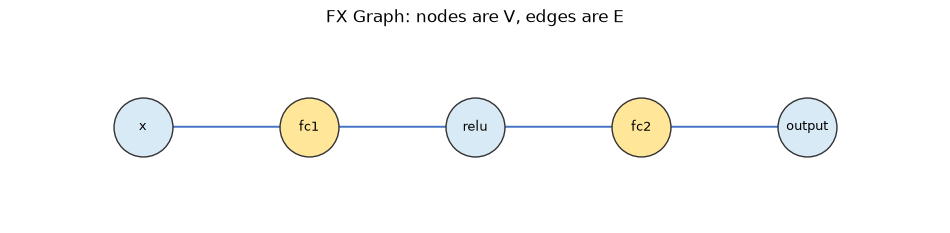

In [7]:
# 一个不依赖 networkx 的小 DAG 可视化。
node_names = [node.name for node in fx_graph.nodes]
positions = {name: (index, 0) for index, name in enumerate(node_names)}

fig, ax = plt.subplots(figsize=(12, 2.5))
for edge in fx_edge_rows:
    source, target = edge["source"], edge["target"]
    x0, y0 = positions[source]
    x1, y1 = positions[target]
    ax.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops={"arrowstyle": "->", "lw": 1.4, "color": "#4472c4"},
    )

for name, (x_pos, y_pos) in positions.items():
    node = next(node for node in fx_graph.nodes if node.name == name)
    color = "#ffe699" if node.op == "call_module" else "#d9eaf7"
    ax.scatter([x_pos], [y_pos], s=1800, color=color, edgecolor="#333333", zorder=3)
    ax.text(x_pos, y_pos, name, ha="center", va="center", fontsize=9, zorder=4)

ax.set_title("FX Graph: nodes are V, edges are E")
ax.set_xlim(-0.8, len(node_names) - 0.2)
ax.set_ylim(-0.7, 0.7)
ax.axis("off")
plt.show()

### 2.4 FX 的边界

FX 很适合观察和改写 Python 模型中的 tensor 数据流，但它不是所有 PyTorch 模型都天然具备的底层 IR：

- eager `nn.Module` 默认只是 Python 对象；
- `symbolic_trace` 需要模型的 Python 控制流可被追踪；
- 动态分支、数据依赖控制流、任意 Python side effect 可能无法直接捕获；
- FX 的 `Graph` 仍然可以保留 `call_module`，距离后端硬件算子还有一层或多层 lowering。

`torch.compile` 的 Dynamo 捕获也经常产出 FX graph，但 `torch.compile` 是更大的编译 pipeline：FX 只是其中一个图表示，不等于整个编译器。

## 3. 用 `torch.export` 得到更强约束的 Export IR

`torch.export.export()` 返回 `ExportedProgram`。它仍然使用 `torch.fx.Graph` / `Node` 作为计算图容器，但额外提供：

- `graph_signature`：每个 placeholder/output 的语义；
- `state_dict`：参数和 buffer 的实际值；
- `call_spec`：原始 Python 参数树如何 flatten/unflatten；
- 更严格的图不变量和 shape 约束。

和普通 FX 的一个直观差别是：参数通常被 lift 成 `placeholder`，而 `nn.Linear` 会下降成 `aten.linear.default`。

In [8]:
exported_raw = torch.export.export(
    model,
    (example_input,),
    strict=True,
)

# 与前一个 notebook 的流程一致：把图变成 ATen dialect。
exported_program = exported_raw.run_decompositions({})

print("ExportedProgram type:", type(exported_program))
print("dialect before decomposition:", getattr(exported_raw, "dialect", None))
print("dialect after decomposition:", getattr(exported_program, "dialect", None))
print("graph is graph_module.graph:", exported_program.graph is exported_program.graph_module.graph)

ExportedProgram type: <class 'torch.export.exported_program.ExportedProgram'>
dialect before decomposition: TRAINING
dialect after decomposition: ATEN
graph is graph_module.graph: True


In [9]:
print(exported_program)

print("\nUser-facing forward:", inspect.signature(exported_program.module().forward))
print("Internal graph forward:", inspect.signature(exported_program.graph_module.forward))
print("state_dict keys:", list(exported_program.state_dict.keys()))
print("call_spec:", exported_program.call_spec)

ExportedProgram:
    class GraphModule(torch.nn.Module):
        def forward(self, p_fc1_weight: "f32[3, 4]", p_fc1_bias: "f32[3]", p_fc2_weight: "f32[2, 3]", p_fc2_bias: "f32[2]", x: "f32[2, 4]"):
             # File: /var/folders/v3/5gqmcs4d02d5d6wzyqyljrcc0000gn/T/ipykernel_48595/3164305414.py:8 in forward, code: hidden = torch.relu(self.fc1(x))
            linear: "f32[2, 3]" = torch.ops.aten.linear.default(x, p_fc1_weight, p_fc1_bias);  x = p_fc1_weight = p_fc1_bias = None
            relu: "f32[2, 3]" = torch.ops.aten.relu.default(linear);  linear = None
            
             # File: /var/folders/v3/5gqmcs4d02d5d6wzyqyljrcc0000gn/T/ipykernel_48595/3164305414.py:9 in forward, code: return self.fc2(hidden)
            linear_1: "f32[2, 2]" = torch.ops.aten.linear.default(relu, p_fc2_weight, p_fc2_bias);  relu = p_fc2_weight = p_fc2_bias = None
            return (linear_1,)
            
Graph signature: ExportGraphSignature(input_specs=[InputSpec(kind=<InputKind.PARAMETER: 2>, 

### 3.1 Export 图的节点、输入和输出

在 `ExportedProgram` 中，`graph.nodes` 仍然是 FX `Node` 对象；变化主要体现在节点语义和图签名。

In [10]:
export_node_rows = []
for node in exported_program.graph.nodes:
    value = node.meta.get("val")
    export_node_rows.append(
        {
            "name": node.name,
            "op": node.op,
            "target": str(node.target),
            "inputs": [item.name for item in node.all_input_nodes],
            "users": [item.name for item in node.users],
            "shape": tuple(value.shape) if value is not None and hasattr(value, "shape") else None,
            "dtype": str(value.dtype) if value is not None and hasattr(value, "dtype") else None,
            "meta_keys": list(node.meta.keys()),
        }
    )

display(pd.DataFrame(export_node_rows))

print("input kinds:", Counter(spec.kind.name for spec in exported_program.graph_signature.input_specs))
print("output specs:")
for spec in exported_program.graph_signature.output_specs:
    print(spec)

,name,op,target,inputs,users,shape,dtype,meta_keys
0,p_fc1_weight,placeholder,p_fc1_weight,[],[linear],"(3, 4)",torch.float32,"[val, tensor_meta, source_fn_stack, from_node,..."
1,p_fc1_bias,placeholder,p_fc1_bias,[],[linear],"(3,)",torch.float32,"[val, tensor_meta, source_fn_stack, from_node,..."
2,p_fc2_weight,placeholder,p_fc2_weight,[],[linear_1],"(2, 3)",torch.float32,"[val, tensor_meta, source_fn_stack, from_node,..."
3,p_fc2_bias,placeholder,p_fc2_bias,[],[linear_1],"(2,)",torch.float32,"[val, tensor_meta, source_fn_stack, from_node,..."
4,x,placeholder,x,[],[linear],"(2, 4)",torch.float32,"[val, tensor_meta]"
5,linear,call_function,aten.linear.default,"[x, p_fc1_weight, p_fc1_bias]",[relu],"(2, 3)",torch.float32,"[stack_trace, nn_module_stack, torch_fn, sourc..."
6,relu,call_function,aten.relu.default,[linear],[linear_1],"(2, 3)",torch.float32,"[stack_trace, nn_module_stack, torch_fn, sourc..."
7,linear_1,call_function,aten.linear.default,"[relu, p_fc2_weight, p_fc2_bias]",[output],"(2, 2)",torch.float32,"[stack_trace, nn_module_stack, torch_fn, sourc..."
8,output,output,output,[linear_1],[],None,NaN,[]


input kinds: Counter({'PARAMETER': 4, 'USER_INPUT': 1})
output specs:
OutputSpec(kind=<OutputKind.USER_OUTPUT: 1>, arg=TensorArgument(name='linear_1'), target=None)


In [11]:
signature = exported_program.graph_signature
placeholders = [node for node in exported_program.graph.nodes if node.op == "placeholder"]

placeholder_rows = []
for node, spec in zip(placeholders, signature.input_specs):
    placeholder_rows.append(
        {
            "placeholder": node.name,
            "kind": spec.kind.name,
            "argument": getattr(spec.arg, "name", spec.arg),
            "target_in_state_dict": spec.target,
        }
    )

display(pd.DataFrame(placeholder_rows))

print("signature convenience views:")
for name in [
    "parameters",
    "buffers",
    "user_inputs",
    "user_outputs",
    "inputs_to_parameters",
    "inputs_to_buffers",
]:
    print(name, "=", getattr(signature, name))

,placeholder,kind,argument,target_in_state_dict
0,p_fc1_weight,PARAMETER,p_fc1_weight,fc1.weight
1,p_fc1_bias,PARAMETER,p_fc1_bias,fc1.bias
2,p_fc2_weight,PARAMETER,p_fc2_weight,fc2.weight
3,p_fc2_bias,PARAMETER,p_fc2_bias,fc2.bias
4,x,USER_INPUT,x,NaN


signature convenience views:
parameters = ('fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias')
buffers = ()
user_inputs = ('x',)
user_outputs = ('linear_1',)
inputs_to_parameters = {'p_fc1_weight': 'fc1.weight', 'p_fc1_bias': 'fc1.bias', 'p_fc2_weight': 'fc2.weight', 'p_fc2_bias': 'fc2.bias'}
inputs_to_buffers = {}


### 3.2 验证 Export 图的 DAG 结构

`ExportedProgram.graph` 的节点顺序是一个可执行的拓扑顺序。下面重新从 `args` / `kwargs` 构造边，并用 `graph.lint()` 做结构检查。

注意：真实模型可能有 buffer mutation、token 或控制流 block；这里的 TinyMLP 是无状态推理图，因此是最简单的 DAG。

In [12]:
export_edge_rows = []
for node in exported_program.graph.nodes:
    for source in collect_node_refs((node.args, node.kwargs)):
        export_edge_rows.append({"source": source.name, "target": node.name})

display(pd.DataFrame(export_edge_rows))
exported_program.graph.lint()
print("Export graph lint: OK")

text_graph_path = ARTIFACT_DIR / "tiny_mlp_export_graph.txt"
text_graph_path.write_text(str(exported_program.graph), encoding="utf-8")
torch.export.save(exported_program, ARTIFACT_DIR / "tiny_mlp_exported.pt2")
print("text graph:", text_graph_path)

,source,target
0,x,linear
1,p_fc1_weight,linear
2,p_fc1_bias,linear
3,linear,relu
4,relu,linear_1
5,p_fc2_weight,linear_1
6,p_fc2_bias,linear_1
7,linear_1,output


Export graph lint: OK
text graph: /Users/yhwang/infer-proj/artifacts/phase0_ir_dag/tiny_mlp_export_graph.txt


## 4. 转为 ONNX：同一个 DAG 换一种容器

ONNX 不是 Python 对象图，而是 protobuf 定义的可移植模型格式：

```text
ModelProto
└── GraphProto
    ├── input: ValueInfoProto
    ├── node: NodeProto[]
    ├── initializer: TensorProto[]
    ├── value_info: ValueInfoProto[]
    └── output: ValueInfoProto
```

ONNX 的边通常不保存为 Python 对象引用，而是通过字符串名字连接：

```text
NodeProto.input  = ["x", "fc1.weight", "fc1.bias"]
NodeProto.output = ["linear"]
```

ONNX 规范要求计算节点按拓扑顺序排列，并且图不能有环。[ONNX IR specification](https://onnx.ai/onnx/repo-docs/IR.html)

In [13]:
# dynamo=True 的 ONNX exporter 会先经过 torch.export，再翻译到 ONNX。
with redirect_stdout(StringIO()), redirect_stderr(StringIO()):
    onnx_program = torch.onnx.export(
        model,
        (example_input,),
        f=None,
        dynamo=True,
        opset_version=18,
        input_names=["x"],
        output_names=["y"],
    )

onnx_proto = onnx_program.model_proto
onnx_path = ARTIFACT_DIR / "tiny_mlp.onnx"
onnx_program.save(onnx_path)

print("ONNXProgram type:", type(onnx_program))
print("ModelProto type:", type(onnx_proto))
print("graph name:", onnx_proto.graph.name)
print("node count:", len(onnx_proto.graph.node))
print("graph inputs:", [(item.name, item.type.tensor_type.shape) for item in onnx_proto.graph.input])
print("graph outputs:", [(item.name, item.type.tensor_type.shape) for item in onnx_proto.graph.output])
print("initializers:", [item.name for item in onnx_proto.graph.initializer])

onnx_node_rows = []
for node in onnx_proto.graph.node:
    onnx_node_rows.append(
        {
            "name": node.name,
            "op_type": node.op_type,
            "domain": node.domain,
            "inputs": list(node.input),
            "outputs": list(node.output),
            "attributes": [attribute.name for attribute in node.attribute],
        }
    )

display(pd.DataFrame(onnx_node_rows))
print("saved:", onnx_path)

W0823 16:17:06.895000 48595 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.


W0823 16:17:06.896000 48595 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.


W0823 16:17:06.897000 48595 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


W0823 16:17:06.898000 48595 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


ONNXProgram type: <class 'torch.onnx.ONNXProgram'>
ModelProto type: <class 'onnx.onnx_ml_pb2.ModelProto'>
graph name: main_graph
node count: 3
graph inputs: [('x', dim {
  dim_value: 2
}
dim {
  dim_value: 4
}
)]
graph outputs: [('y', dim {
  dim_value: 2
}
dim {
  dim_value: 2
}
)]
initializers: ['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias']


,name,op_type,domain,inputs,outputs,attributes
0,node_Gemm_0,Gemm,,"[x, fc1.weight, fc1.bias]",[linear],"[beta, transB, alpha, transA]"
1,node_Relu_1,Relu,,[linear],[relu],[]
2,node_Gemm_2,Gemm,,"[relu, fc2.weight, fc2.bias]",[y],"[beta, transB, alpha, transA]"


saved: /Users/yhwang/infer-proj/artifacts/phase0_ir_dag/tiny_mlp.onnx


这里可以看到一个重要差异：

- PyTorch FX 的边是 `Node` 对象引用；
- ONNX 的边是 tensor/value 名称字符串；
- ONNX 的参数通常在 `initializer` 中；
- ONNX 的中间 tensor 类型/形状在 `ValueInfoProto` 中，而不是挂在 Python `Node.meta` 上。

## 5. 转为 Core ML MIL：面向 Core ML backend 的 IR

Core ML Tools 的 converter 会先把 PyTorch/TorchScript 转成 MIL，再经过 MIL passes，最后生成 Core ML `mlprogram` 或其他格式。

MIL 的核心结构可以理解为：

```text
Program
└── functions["main"]
    └── Block
        └── Operation[]
            ├── op_type
            ├── inputs: 命名输入 -> Var
            └── outputs: Var[]
```

MIL 的特点：

- operation 的输入通常是有名字的，例如 `x=...`、`weight=...`；
- tensor 输出是 `Var`；
- shape/dtype 通过 `Var.sym_type` 表达；
- 权重常常被 materialize 成 `const` operation；
- converter 可能插入 `cast`、`const` 等节点，因此不会和 FX/ONNX 一一对应。

参考：[Model Intermediate Language](https://apple.github.io/coremltools/docs-guides/source/model-intermediate-language.html)

In [14]:
traced_model = torch.jit.trace(model, example_input)

# 只取 MIL 内部程序，方便学习 IR；不在这里执行 Core ML runtime。
with redirect_stdout(StringIO()), redirect_stderr(StringIO()):
    mil_program = ct.convert(
        traced_model,
        convert_to="milinternal",
        inputs=[ct.TensorType(name="x", shape=tuple(example_input.shape))],
    )

mil_main = mil_program.functions["main"]
print("MIL Program type:", type(mil_program))
print("main Function type:", type(mil_main))
print("operation count:", len(mil_main.operations))
print("\nMIL textual IR:\n")
print(mil_program)

MIL Program type: <class 'coremltools.converters.mil.mil.program.Program'>
main Function type: <class 'coremltools.converters.mil.mil.block.Function'>
operation count: 11

MIL textual IR:


main[CoreML3](%x: (2, 4, fp32)(Tensor)) {
  block0() {
    %x_to_fp16: (2, 4, fp16)(Tensor) = cast(x=%x, dtype="fp16", name="cast_1")
    %linear_0_cast_fp16: (2, 3, fp16)(Tensor) = linear(x=%x_to_fp16, weight=%fc1.weight_to_fp16, bias=[-0.477783203125, -0.3310546875, -0.2060546875], name="linear_0_cast_fp16")
    %input_cast_fp16: (2, 3, fp16)(Tensor) = relu(x=%linear_0_cast_fp16, name="input_cast_fp16")
    %linear_1_cast_fp16: (2, 2, fp16)(Tensor) = linear(x=%input_cast_fp16, weight=[[0.021392822265625, 0.228271484375, 0.346435546875], [-0.391357421875, -0.25146484375, 0.209716796875]], bias=[0.4794921875, -0.11883544921875], name="linear_1_cast_fp16")
    %var_10: (2, 2, fp32)(Tensor) = cast(x=%linear_1_cast_fp16, dtype="fp32", name="cast_0")
  } -> (%var_10)
}



In [15]:
def mil_value_name(value):
    if hasattr(value, "name"):
        return value.name
    if isinstance(value, (tuple, list)):
        return [mil_value_name(item) for item in value]
    return repr(value)


mil_rows = []
for operation in mil_main.operations:
    output_vars = operation.outputs
    first_output = output_vars[0] if output_vars else None
    mil_rows.append(
        {
            "name": operation.name,
            "op_type": operation.op_type,
            "inputs": {
                name: mil_value_name(value)
                for name, value in operation.inputs.items()
            },
            "outputs": [value.name for value in output_vars],
            "output_shape": getattr(first_output, "shape", None),
            "output_sym_type": str(getattr(first_output, "sym_type", None)),
        }
    )

display(pd.DataFrame(mil_rows))

,name,op_type,inputs,outputs,output_shape,output_sym_type
0,x_to_fp16_dtype_0,const,{},[x_to_fp16_dtype_0],(),<class 'coremltools.converters.mil.mil.types.t...
1,fc1.weight_to_fp16,const,{},[fc1.weight_to_fp16],"(3, 4)",<class 'coremltools.converters.mil.mil.types.t...
2,fc1.bias_to_fp16,const,{},[fc1.bias_to_fp16],"(3,)",<class 'coremltools.converters.mil.mil.types.t...
3,cast_1,cast,"{'x': 'x', 'dtype': 'x_to_fp16_dtype_0'}",[x_to_fp16],"(2, 4)",<class 'coremltools.converters.mil.mil.types.t...
4,linear_0_cast_fp16,linear,"{'x': 'x_to_fp16', 'weight': 'fc1.weight_to_fp...",[linear_0_cast_fp16],"(2, 3)",<class 'coremltools.converters.mil.mil.types.t...
5,input_cast_fp16,relu,{'x': 'linear_0_cast_fp16'},[input_cast_fp16],"(2, 3)",<class 'coremltools.converters.mil.mil.types.t...
6,fc2.weight_to_fp16,const,{},[fc2.weight_to_fp16],"(2, 3)",<class 'coremltools.converters.mil.mil.types.t...
7,fc2.bias_to_fp16,const,{},[fc2.bias_to_fp16],"(2,)",<class 'coremltools.converters.mil.mil.types.t...
8,linear_1_cast_fp16,linear,"{'x': 'input_cast_fp16', 'weight': 'fc2.weight...",[linear_1_cast_fp16],"(2, 2)",<class 'coremltools.converters.mil.mil.types.t...
9,linear_1_cast_fp16_to_fp32_dtype_0,const,{},[linear_1_cast_fp16_to_fp32_dtype_0],(),<class 'coremltools.converters.mil.mil.types.t...


## 6. 四种表示的共同点和差异

共同点是它们都在回答同一组问题：

1. 有哪些计算节点？
2. 每个节点执行什么操作？
3. 它依赖哪些输入值？
4. 它产生哪些输出值？
5. 输入输出的 shape、dtype、常量和属性是什么？
6. 节点之间是否可以按拓扑顺序执行？

差异主要在于“节点/边/类型/参数”如何编码，以及这个 IR 服务于哪一个 backend。

In [16]:
comparison = pd.DataFrame(
    [
        {
            "IR": "torch.fx",
            "container": "GraphModule -> Graph -> Node",
            "node op": "node.op + node.target",
            "edge": "Node object references in args/users",
            "tensor attrs": "node.meta after ShapeProp",
            "weights": "module attributes / state_dict; may be call_module",
            "main use": "PyTorch tracing, graph rewrite, compiler frontend",
        },
        {
            "IR": "torch.export",
            "container": "ExportedProgram + FX Graph",
            "node op": "usually ATen OpOverload",
            "edge": "Node object references",
            "tensor attrs": "node.meta['val'] / tensor_meta",
            "weights": "lifted placeholders + graph_signature + state_dict",
            "main use": "stronger export contract and backend lowering",
        },
        {
            "IR": "ONNX",
            "container": "ModelProto -> GraphProto",
            "node op": "NodeProto.op_type/domain/attribute",
            "edge": "named tensor strings",
            "tensor attrs": "ValueInfoProto type/shape",
            "weights": "GraphProto.initializer TensorProto",
            "main use": "portable interchange format",
        },
        {
            "IR": "Core ML MIL",
            "container": "Program -> Function -> Block -> Operation",
            "node op": "Operation.op_type",
            "edge": "named inputs pointing to Var",
            "tensor attrs": "Var.sym_type / shape / dtype",
            "weights": "usually const operations or const inputs",
            "main use": "Core ML conversion and backend optimization",
        },
    ]
)

display(comparison)

,IR,container,node op,edge,tensor attrs,weights,main use
0,torch.fx,GraphModule -> Graph -> Node,node.op + node.target,Node object references in args/users,node.meta after ShapeProp,module attributes / state_dict; may be call_mo...,"PyTorch tracing, graph rewrite, compiler frontend"
1,torch.export,ExportedProgram + FX Graph,usually ATen OpOverload,Node object references,node.meta['val'] / tensor_meta,lifted placeholders + graph_signature + state_...,stronger export contract and backend lowering
2,ONNX,ModelProto -> GraphProto,NodeProto.op_type/domain/attribute,named tensor strings,ValueInfoProto type/shape,GraphProto.initializer TensorProto,portable interchange format
3,Core ML MIL,Program -> Function -> Block -> Operation,Operation.op_type,named inputs pointing to Var,Var.sym_type / shape / dtype,usually const operations or const inputs,Core ML conversion and backend optimization


## 7. 端到端一致性检查

结构相似不代表数值一定一致，所以用同一个输入分别执行：

```text
PyTorch eager
FX GraphModule
ExportedProgram.module()
ONNX Runtime
```

Core ML MIL 在本单元只检查结构；实际 `.predict()` 需要在 macOS 的 Core ML runtime 环境中执行。

In [17]:
with torch.no_grad():
    fx_output = fx_module(example_input)
    exported_output = exported_program.module()(example_input)

onnx_session = ort.InferenceSession(
    str(onnx_path),
    providers=["CPUExecutionProvider"],
)
onnx_output = onnx_session.run(
    None,
    {"x": example_input.numpy()},
)[0]

torch.testing.assert_close(eager_output, fx_output)
torch.testing.assert_close(eager_output, exported_output[0] if isinstance(exported_output, tuple) else exported_output)
np.testing.assert_allclose(
    eager_output.numpy(),
    onnx_output,
    rtol=1e-5,
    atol=1e-5,
)

print("eager vs FX: OK")
print("eager vs torch.export: OK")
print("eager vs ONNX Runtime: OK")
print("Core ML MIL structure inspected; runtime prediction is a separate macOS check.")

eager vs FX: OK
eager vs torch.export: OK
eager vs ONNX Runtime: OK
Core ML MIL structure inspected; runtime prediction is a separate macOS check.


## Takeaways

- `nn.Module` 是 eager Python 模型对象，不是天然的 FX 图。
- FX 是 PyTorch 体系中的一种 graph/IR 表示；`torch.compile`、`torch.export` 等流程可以使用它，但 FX 不等于整个 PyTorch 编译器。
- 节点通常描述“操作类型 + 输入值引用 + 输出值名字 + 可选类型/shape metadata”。
- 在简单 DAG 中，边就是节点之间的数据依赖：一个节点的输出被另一个节点的 `args` / named input 引用。
- FX、`torch.export`、ONNX、MIL 都表达 dataflow，但容器和边编码不同：对象引用、字符串名字、`Var` 引用分别对应不同生态。
- 节点数不是最终 kernel 数。后续 lowering 可能做 operator fusion、layout transform、cast insertion 和 memory planning。

下一步可以在这个 TinyMLP 上继续观察：`torch.compile` 的 graph break、ONNX Runtime 的 optimized graph、Core ML `compute_plan`，再把同样的检查迁移到 ResNet-50。